# Benchmark 3T3L1 Tree and Benchmark Summary

## Preprocessing
- Example nexflow command to generate result

```bash
#!/bin/bash

nextflow run ~/software/RETrace2/main.nf \
            --samplesheet 20240319_3T3L1_samplesheet.csv \
            --output_dir results_10000targets_3000cpgs_minqual0.9_run2\
            --output_prefix 20240319_3T3L1 \
            --genome_base ~/Projects/GenomeDB \
            --genome mm39 \
            --target_bed /home/tcheng/software/RETrace2/resources/targets/mm39/RETrace2.mm39.1nt10-30bp.92460targets169818probes.bed \
            --min_targets 10000 \
            --min_cpgs 3000 \
            --min_qual 0.9 \
            --run_methylation \
            --circular_tree \
            -profile docker \
            -resume \
```

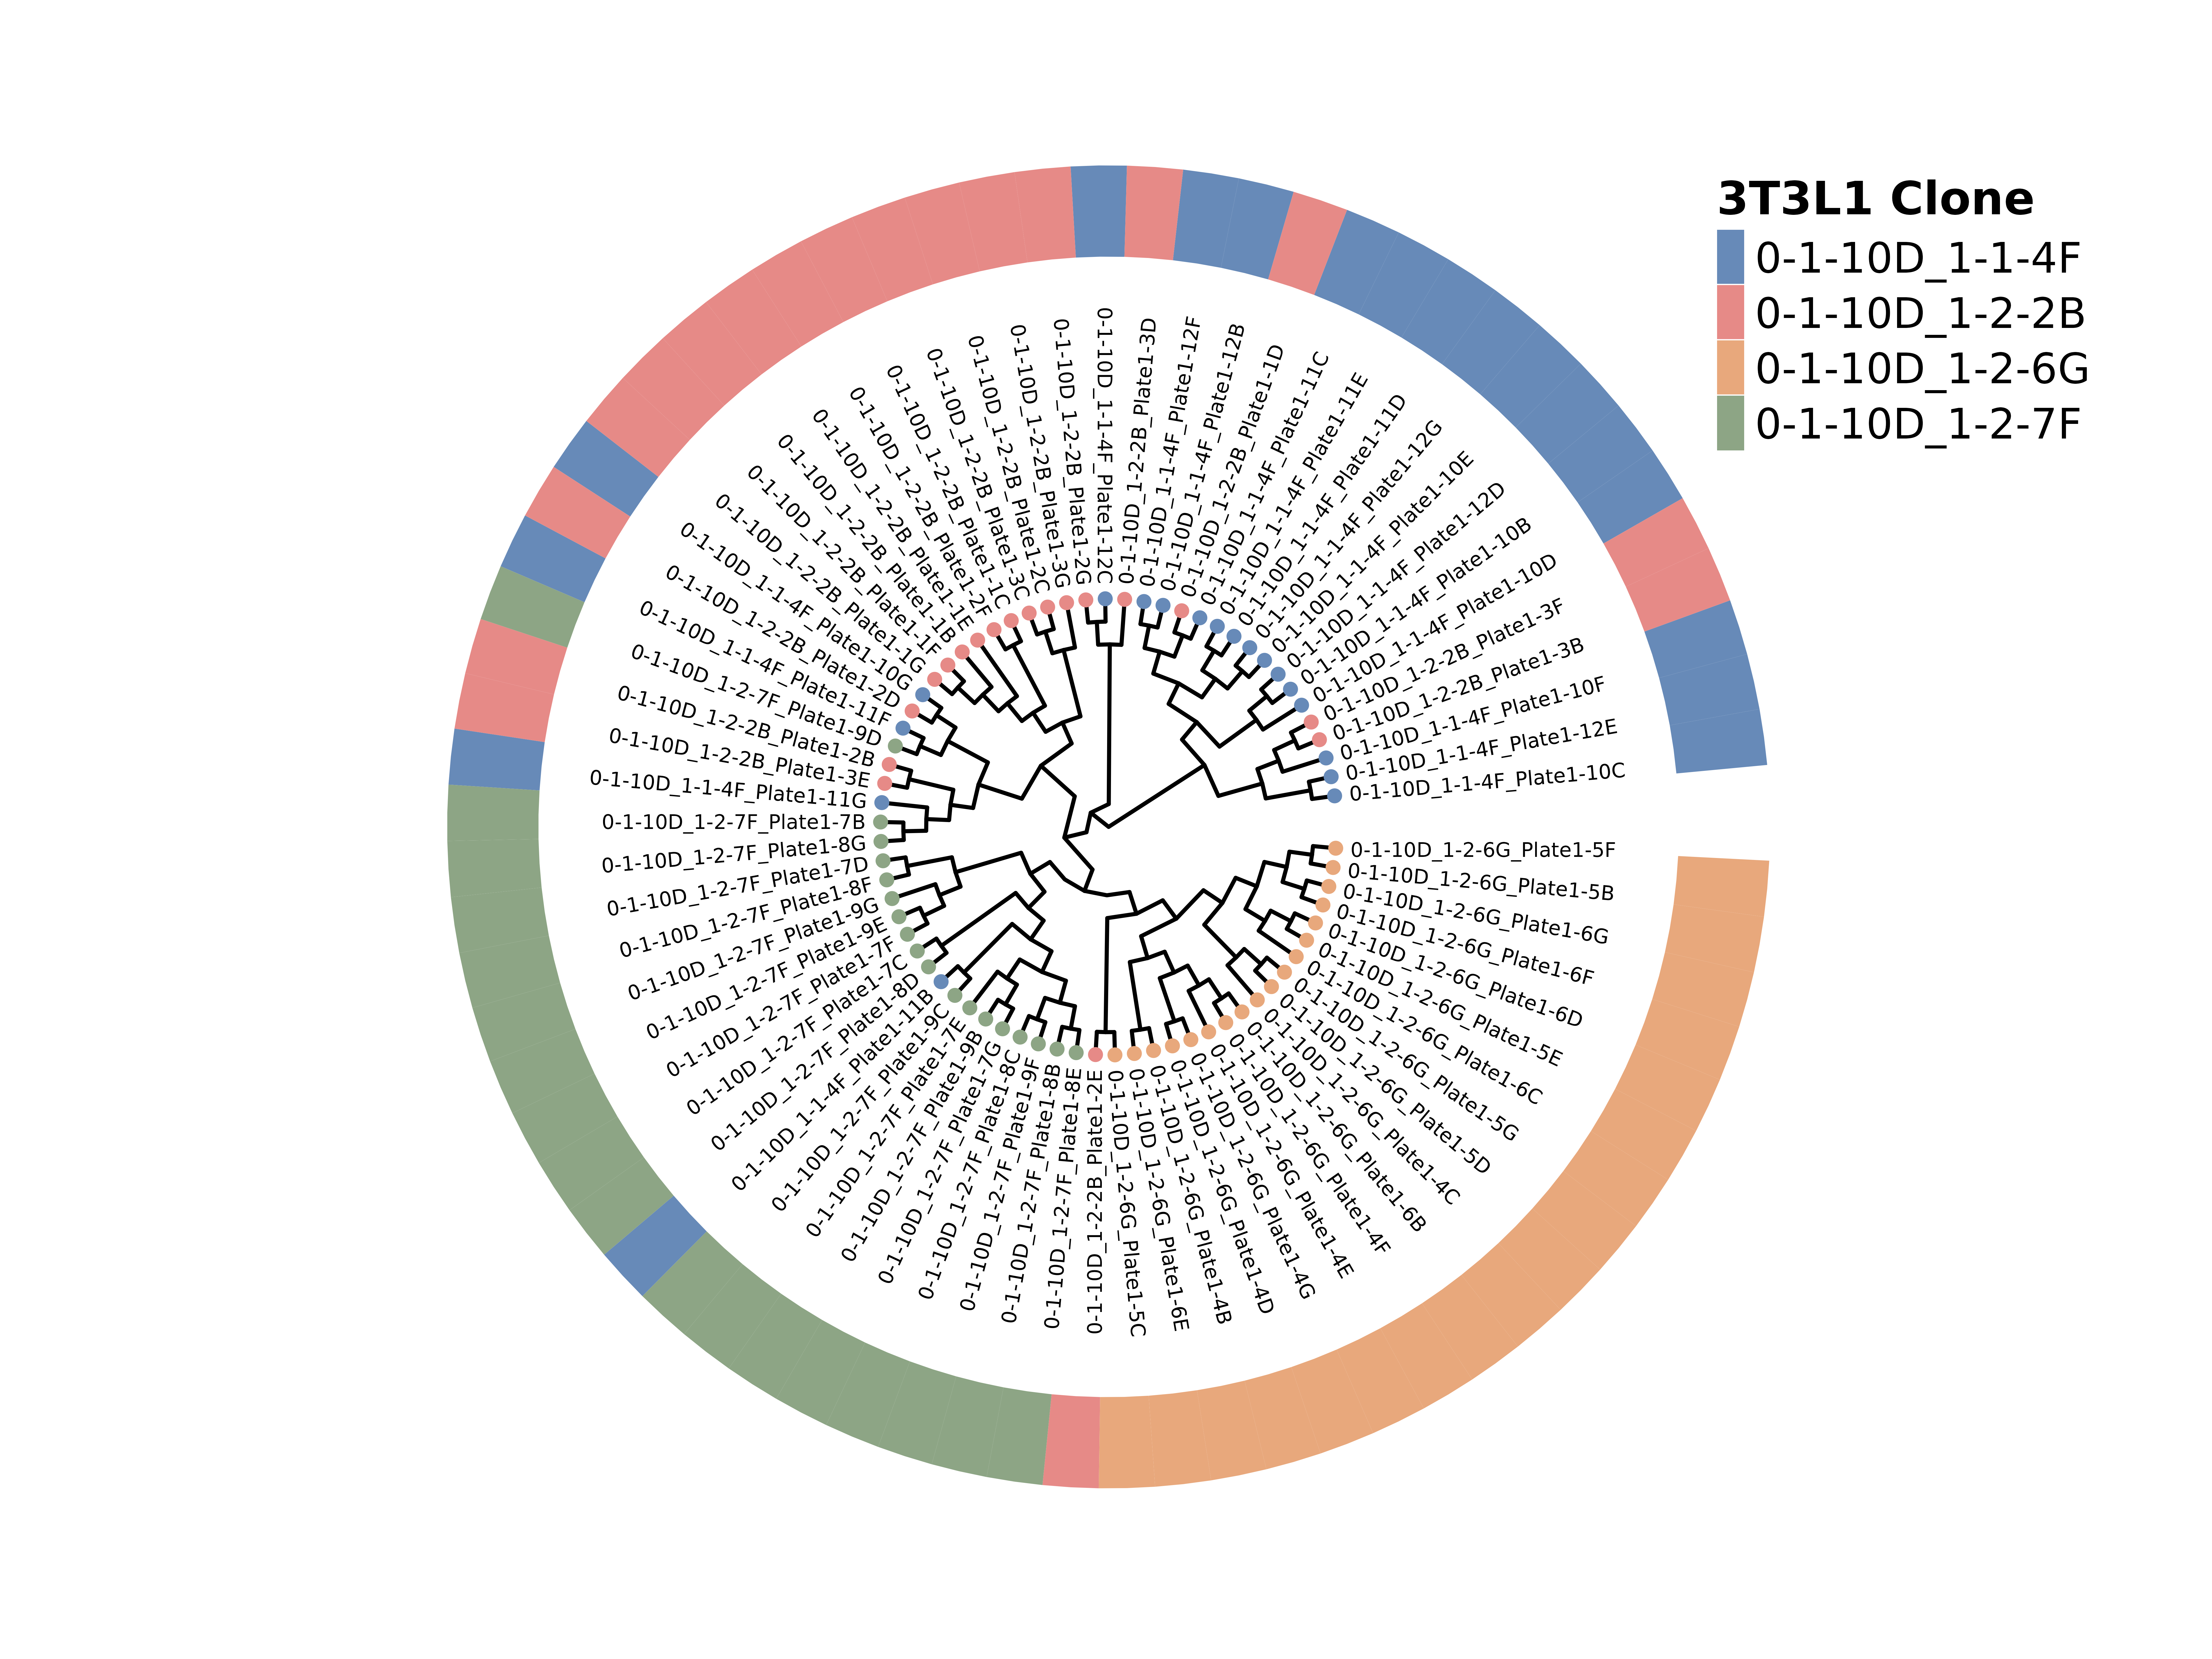

In [1]:
from IPython.display import Image

# First plot for di- to hexanucleotide
display(Image("/home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/20240319_3T3L1_10000targets_minqual0.9_circular_ggtree.viewPhylo.png"))

```bash
#!/bin/bash
# Run evalPhylo script to get tree accuracy
python /home/tcheng/software/RETrace2/scripts/evalPhylo.py \
    --samplesheet /home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/20240319_3T3L1_samplesheet.csv \
    --tree /home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/results_10000targets_3000cpgs_minqual0.9_run2/phylo/20240319_3T3L1.buildPhylo.newick-original.txt \
    --prefix 3T3L1_10000targets_minqual0.9_run2 \
    --distDict /home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/results_10000targets_3000cpgs_minqual0.9_run2/phylo/20240319_3T3L1.buildPhylo.distDict.pkl \
    --exVivo_rootDist /home/tcheng/software/RETrace/Data/Cell_tree/3T3L1_exVivo/3T3L1_exVivo.rootDist.csv \
    --nproc 10

```

# Plot Benchmark Summary
- Run example command like above to generate result and tree accuracy for each library
- Note: there could be some stochasticity in processing pipeline (eg. BAW MEM, HipSTR), so the accuracy could vary slightly between runs

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
data = pd.DataFrame({'Assay':['RETrace v1', 'RETrace v1', 'RETrace v2', 'RETrace v2'],
                     'cell':['HCT116', 'U87MG', 'HCT116','3T3L1'],
                     'Microsatellite Stability':['Unstable', 'Stable', 'Unstable','Stable'],
                     'accuracy_perc':[88, 33, 100, 70],
                     'cell_div':[184, 184, 3, 62]})
data

,Assay,cell,Microsatellite Stability,accuracy_perc,cell_div
0,RETrace v1,HCT116,Unstable,88,184
1,RETrace v1,U87MG,Stable,33,184
2,RETrace v2,HCT116,Unstable,100,3
3,RETrace v2,3T3L1,Stable,70,62


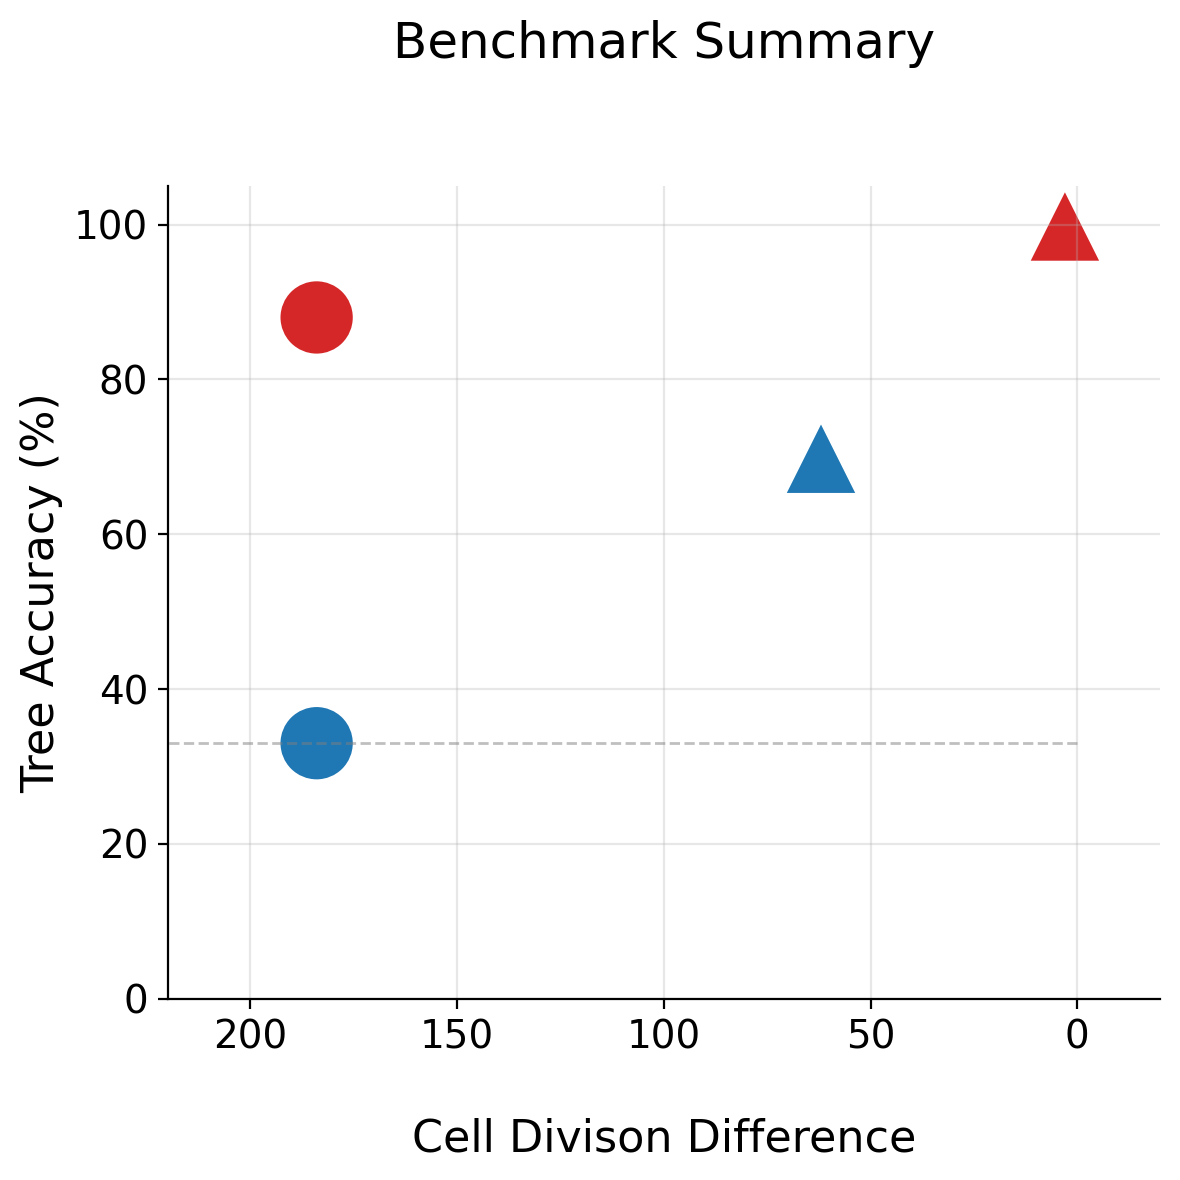

In [4]:
fig, ax = plt.subplots(figsize=(6,6), dpi=200)

custom_palette = { 'Stable': 'tab:blue', 'Unstable': 'tab:red'}
sns.scatterplot(data=data, x='cell_div', y='accuracy_perc', hue='Microsatellite Stability', s=800, style ='Assay',
                markers={'RETrace v1': 'o', 'RETrace v2': '^'}, palette=custom_palette, legend=False)

ax.set_title('Benchmark Summary\n\n', fontsize=18)
ax.set_ylabel('Tree Accuracy (%)', fontsize=16)
ax.set_xlabel('\nCell Divison Difference', fontsize=16)

ax.grid(True, axis='both', alpha=0.3)
ax.set_xlim(-20,220)
ax.set_xticks([0, 50, 100, 150, 200])
ax.set_ylim(0,105)
#ax.yaxis.set_label_position("right")
#ax.yaxis.tick_right()
ax.invert_xaxis()
ax.tick_params(axis='both', labelsize=14)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.hlines(33, 0, 220, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('3T3L1_BenchmarkSummary.pdf')
plt.show()

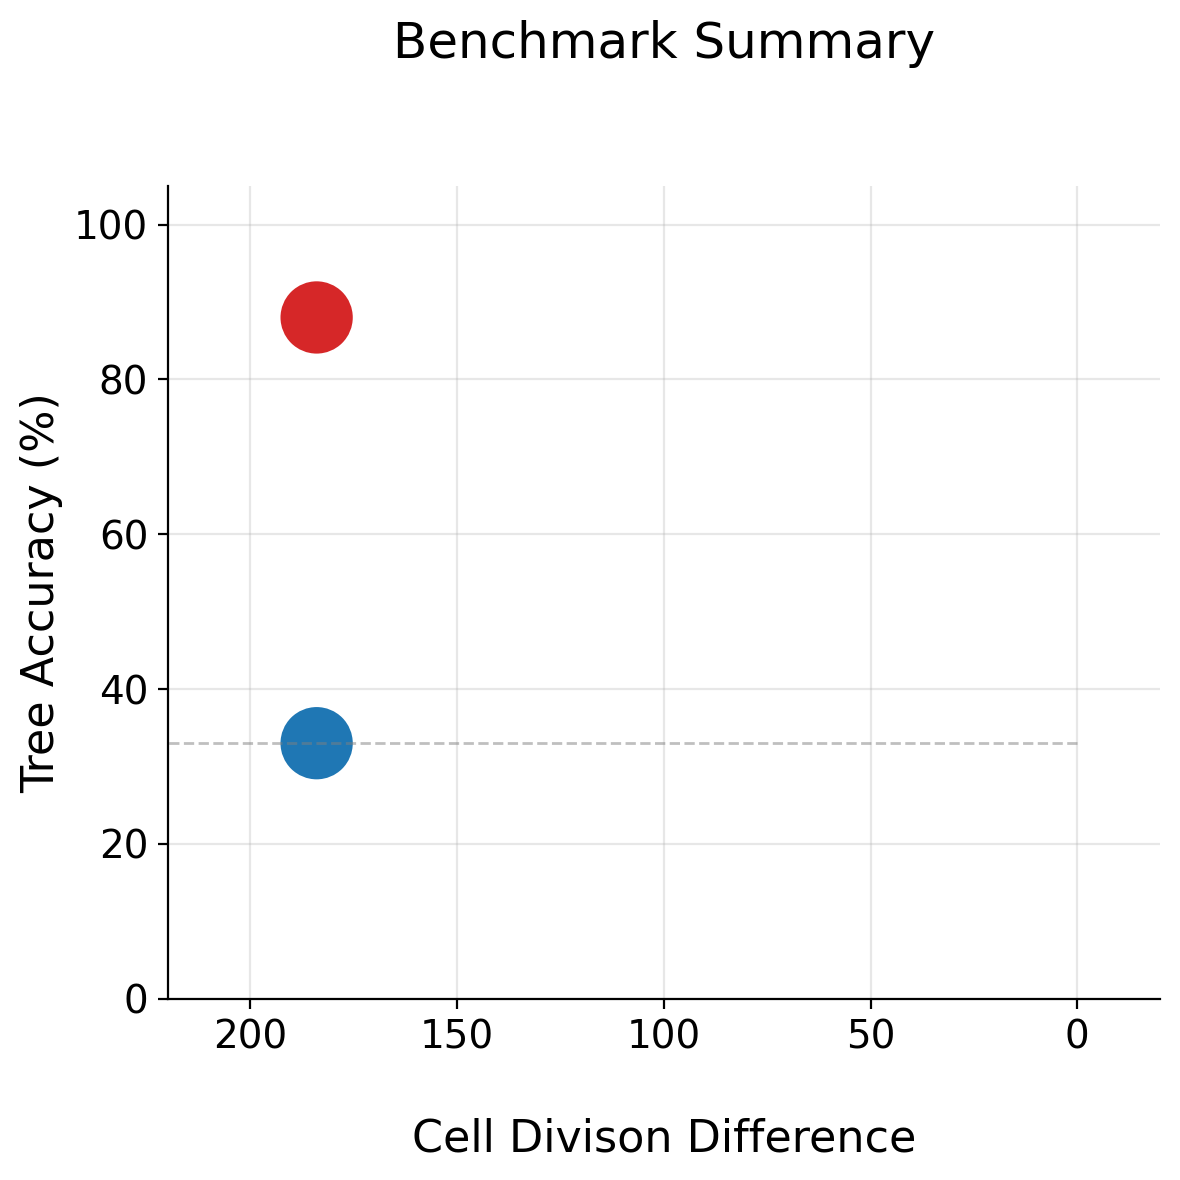

In [5]:
# Plot RETrace v1 only
data = data[data['Assay'] == 'RETrace v1']

fig, ax = plt.subplots(figsize=(6,6), dpi=200)

custom_palette = { 'Stable': 'tab:blue', 'Unstable': 'tab:red'}
sns.scatterplot(data=data, x='cell_div', y='accuracy_perc', hue='Microsatellite Stability', s=800, style ='Assay',
                markers={'RETrace v1': 'o', 'RETrace v2': '^'}, palette=custom_palette, legend=False)

ax.set_title('Benchmark Summary\n\n', fontsize=18)
ax.set_ylabel('Tree Accuracy (%)', fontsize=16)
ax.set_xlabel('\nCell Divison Difference', fontsize=16)

ax.grid(True, axis='both', alpha=0.3)
ax.set_xlim(-20,220)
ax.set_xticks([0, 50, 100, 150, 200])
ax.set_ylim(0,105)
#ax.yaxis.set_label_position("right")
#ax.yaxis.tick_right()
ax.invert_xaxis()
ax.tick_params(axis='both', labelsize=14)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.hlines(33, 0, 220, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('3T3L1_BenchmarkSummary_RETracev1.png', dpi=200)
plt.show()